### This Notebook was used as part of the Kaggle Competition from data of the 1C Company from Russia.
##### It contains Data Load and Cleaning, Feature preprocessing, Feature creation, Hyper parameters tuning and 2 level Stacking


#### Description

In this competition you will work with a challenging time-series dataset consisting of daily sales data, kindly provided by one of the largest Russian software firms - 1C Company. 

We are asking you to predict total sales for every product and store in the next month. By solving this competition you will be able to apply and enhance your data science skills.

You are provided with daily historical sales data. The task is to forecast the total amount of products sold in every shop for the test set. Note that the list of shops and products slightly changes every month. Creating a robust model that can handle such situations is part of the challenge.

#### File descriptions
- sales_train.csv - the training set. Daily historical data from January 2013 to October 2015.
- test.csv - the test set. You need to forecast the sales for these shops and products for November 2015.
- sample_submission.csv - a sample submission file in the correct format.
- items.csv - supplemental information about the items/products.
- item_categories.csv  - supplemental information about the items categories.
- shops.csv- supplemental information about the shops.

#### Data fields
ID - an Id that represents a (Shop, Item) tuple within the test set
shop_id - unique identifier of a shop
item_id - unique identifier of a product
item_category_id - unique identifier of item category
item_cnt_day - number of products sold. You are predicting a monthly amount of this measure
item_price - current price of an item
date - date in format dd/mm/yyyy
date_block_num - a consecutive month number, used for convenience. January 2013 is 0, February 2013 is 1,..., October 2015 is 33
item_name - name of item
shop_name - name of shop
item_category_name - name of item category

This dataset is permitted to be used for any purpose, including commercial use. More info in: https://www.kaggle.com/c/competitive-data-science-predict-future-sales/overview

# Setup

In [1]:
import os
import warnings
from pathlib import Path
import math
import gc
import dask
import dask.dataframe as dd

# Data Manipulation 
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
# import modin.pandas as pd
from pandas.api.types import CategoricalDtype
from IPython.display import display

# Visualization 
import matplotlib.pyplot as plt
import missingno
import seaborn as sns
from pandas.plotting import scatter_matrix
from mpl_toolkits.mplot3d import Axes3D

# Feature Selection and Encoding
from sklearn.feature_selection import RFE, RFECV, mutual_info_regression
from sklearn.svm import SVR

#Feature imputation
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, label_binarize
from category_encoders import MEstimateEncoder

# Dimensionality Reduction / Clustering
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

#Model selection
from sklearn.model_selection import KFold, cross_val_score, train_test_split

# Machine learning 
from xgboost import XGBRegressor
import sklearn.ensemble as ske
from sklearn import datasets, model_selection, tree, preprocessing, metrics, linear_model
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgb
# import tensorflow as tf

# Grid and Random Search
import scipy.stats as st
from scipy.stats import randint as sp_randint
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Metrics
from sklearn.metrics import precision_recall_fscore_support, roc_curve, auc

# Set Matplotlib defaults
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)

# Plot the Figures Inline
%matplotlib inline

# Mute warnings
warnings.filterwarnings('ignore')

%matplotlib inline 

pd.set_option('display.max_rows', 600)
pd.set_option('display.max_columns', 50)

# import lightgbm as lgb
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from tqdm import tqdm_notebook

from itertools import product

print("Setup done")

Setup done


In [2]:
data_dir=Path('1C-predict-future-sales-data/')



df_train=pd.read_csv(data_dir / "sales_train.csv")
df_test=pd.read_csv(data_dir / "test.csv").set_index('ID')
items=pd.read_csv(data_dir / "items.csv")
df_shops=pd.read_csv(data_dir / "shops.csv").set_index('shop_id')
df_item_cat=pd.read_csv(data_dir / "item_categories.csv").set_index('item_category_id')

In [3]:
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))

    return df

df_train = reduce_mem_usage(df_train)
df_test = reduce_mem_usage(df_test)

Memory usage after optimization is: 50.40 MB
Decreased by 62.5%
Memory usage after optimization is: 2.25 MB
Decreased by 54.2%


In [4]:
df_train.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
0,02.01.2013,0,59,22154,999.000000,1.0
1,03.01.2013,0,25,2552,899.000000,1.0
2,05.01.2013,0,25,2552,899.000000,-1.0
3,06.01.2013,0,25,2554,1709.050049,1.0
4,15.01.2013,0,25,2555,1099.000000,1.0


### Pre-Processing

#### Outlier detection: Price

<AxesSubplot:xlabel='item_price'>

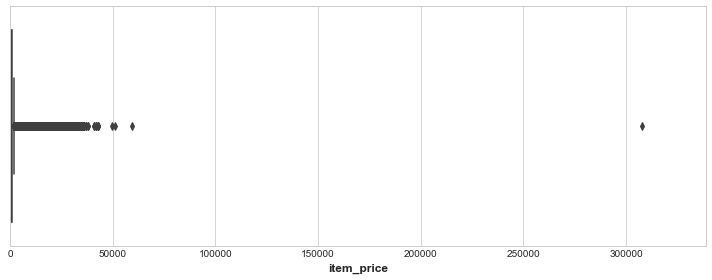

In [5]:
plt.figure(figsize=(10,4))

plt.xlim(df_train.item_price.min(), df_train.item_price.max()*1.1)
sns.boxplot(x=df_train.item_price)

#### Outlier detection: Quantity

<AxesSubplot:xlabel='item_cnt_day'>

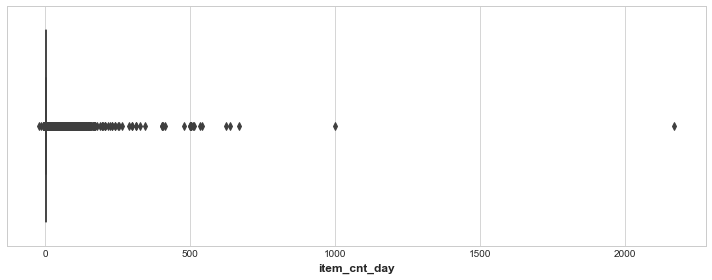

In [6]:
plt.figure(figsize=(10,4))
plt.ylim(df_train.item_cnt_day.min()-1,df_train.item_cnt_day.max()+1)
sns.boxplot(x=df_train.item_cnt_day)

In [7]:
df_train = df_train[df_train.item_price<100000]
df_train = df_train[df_train.item_cnt_day<1001]

In [8]:
# Found a negative price => we imput the median instead
median = (df_train[
    
    (df_train.shop_id==32)&
    (df_train.item_id==2973)&
    (df_train.date_block_num==4)&
    (df_train.item_price>0)
    
    ]
    .item_price.median())
          
df_train.loc[df_train.item_price<0, 'item_price'] = median

In [9]:
#Guided by their names, some shops are names are slightly different but correspond to the same shop in fact
# => we correct the IDs

# Якутск Орджоникидзе, 56
df_train.loc[df_train.shop_id == 0, 'shop_id'] = 57
df_test.loc[df_test.shop_id == 0, 'shop_id'] = 57
# Якутск ТЦ "Центральный"
df_train.loc[df_train.shop_id == 1, 'shop_id'] = 58
df_test.loc[df_test.shop_id == 1, 'shop_id'] = 58
# Жуковский ул. Чкалова 39м²
df_train.loc[df_train.shop_id == 10, 'shop_id'] = 11
df_test.loc[df_test.shop_id == 10, 'shop_id'] = 11

In [10]:
#We extract the City from the Shop name and add it as info/feature in df_shops

shops=df_shops.reset_index()

shops.loc[shops.shop_name == 'Сергиев Посад ТЦ "7Я"', 'shop_name'] = 'СергиевПосад ТЦ "7Я"'
shops['city'] = shops['shop_name'].str.split(' ').map(lambda x: x[0])
shops.loc[shops.city == '!Якутск', 'city'] = 'Якутск'
shops['city_code'] = LabelEncoder().fit_transform(shops['city'])
df_shops = shops[['shop_id','city_code']]

In [11]:
#We split item cat in type & subtype

df_item_cat=df_item_cat.reset_index()
df_item_cat['split'] = df_item_cat['item_category_name'].str.split('-')
df_item_cat['type'] = df_item_cat['split'].map(lambda x: x[0].strip())
df_item_cat['type_code'] = LabelEncoder().fit_transform(df_item_cat['type'])
# if subtype is nan then type
df_item_cat['subtype'] = df_item_cat['split'].map(lambda x: x[1].strip() if len(x) > 1 else x[0].strip())
df_item_cat['subtype_code'] = LabelEncoder().fit_transform(df_item_cat['subtype'])
df_item_cat = df_item_cat[['item_category_id','type_code', 'subtype_code']]

In [12]:
#Extra feature: Revenue

df_train['revenue'] = df_train['item_price'] *  df_train['item_cnt_day']

# EDA

## Sets inspection

In [13]:
#By doing df_test.nunique() we discover that the 214 200 rows of df_test comes 
#from the combination of unique shop_id (42) and item_id (5100 combinations)
df_test.nunique()

shop_id      42
item_id    5100
dtype: int64

In [14]:
#Check if shops in test are contained in train : OK

list_shops_test=df_test.shop_id.unique()
list_shops_train=df_train.shop_id.unique()
set(list_shops_test).issubset(set(list_shops_train))

True

In [15]:
#Check if items in test are contained in train : KO

list_items_test=df_test.item_id.unique()
list_items_train=df_train.item_id.unique()
set(list_items_test).issubset(set(list_items_train))

False

In [16]:
#Check how many items from test are present in train:

test_items_in_train=list(set(list_items_test).intersection(list_items_train))
test_items_in_train=list(set(list_items_test).intersection(list_items_train))
test_items_not_in_train=list(set(list_items_test).difference(list_items_train))

print('Test contains {} items of which {} are in train and {} which are not'.format
      (len(list_items_test),len(test_items_in_train),len(test_items_not_in_train)))

df_test[df_test.item_id.isin(test_items_not_in_train)]

Test contains 5100 items of which 4737 are in train and 363 which are not


,shop_id,item_id
ID,,
1,5,5320
4,5,5268
45,5,5826
64,5,3538
65,5,3571
...,...,...
214130,45,15033
214150,45,7572
214154,45,9030


In [17]:
# By doing value_counts(), we see that df_train only has item+shop combinations with item_cnt>=1
#=> we need to account for that by creating a grid, manually inserting the 0 for the days without sales

df_train.item_cnt_day.value_counts().head(5)

1.0    2629371
2.0     194201
3.0      47350
4.0      19685
5.0      10474
Name: item_cnt_day, dtype: int64

## Grid creation

##### We see that 99% of average item x shop monthly sales fall below 20
##### => we can clip values from 0 to 20

In [19]:
sales=df_train

df_test['date_block_num']=34
df_test.head()

# Create "grid" with columns
index_cols = ['shop_id', 'item_id', 'date_block_num']

# For every month we create a grid from all shops/items combinations from that month
grid = [] 
for block_num in sales['date_block_num'].unique():
    cur_shops = sales.loc[sales['date_block_num'] == block_num, 'shop_id'].unique()
    cur_items = sales.loc[sales['date_block_num'] == block_num, 'item_id'].unique()
    grid.append(np.array(list(product(*[cur_shops, cur_items, [block_num]])),dtype='int32'))

# Turn the grid into a dataframe
grid = pd.DataFrame(np.vstack(grid), columns = index_cols,dtype=np.int32)

# Groupby data to get shop-item-month aggregates

gb = sales.groupby(index_cols,as_index=False).agg({'item_cnt_day':'sum'})
gb = reduce_mem_usage(gb)

# Fix column names
 
gb = gb.rename(columns={'item_cnt_day':'target'})
# Join it to the grid
all_data = pd.merge(grid, gb, how='left', on=index_cols).fillna(0)
all_data['target']=all_data['target'].astype('int16')
all_data['target']=all_data['target'].clip(0,20)
#all_data = reduce_mem_usage(all_data)
                           
del gb;
gc.collect();

# Same as above but with shop-month aggregates


gb = sales.groupby(['shop_id', 'date_block_num'],as_index=False).agg({'item_cnt_day':'sum'})
gb = gb.rename(columns={'item_cnt_day':'target_shop'})
gb = reduce_mem_usage(gb)

all_data = pd.merge(all_data, gb, how='left', on=['shop_id', 'date_block_num']).fillna(0)

# all_data = reduce_mem_usage(all_data)

del gb;
gc.collect();

# Same as above but with item-month aggregates
# gb = sales.groupby(['item_id', 'date_block_num'],as_index=False).agg({'item_cnt_day':{'target_item':'sum'}})
# gb.columns = [col[0] if col[-1] == '' else col[-1] for col in gb.columns.values]

gb = sales.groupby(['item_id', 'date_block_num'],as_index=False).agg({'item_cnt_day':'sum'})
gb = gb.rename(columns={'item_cnt_day':'target_item'})
gb = reduce_mem_usage(gb)

all_data = pd.merge(all_data, gb, how='left', on=['item_id', 'date_block_num']).fillna(0)
##add item cat
all_data = pd.merge(all_data,items[['item_id','item_category_id']],how='left',on='item_id')
## add type and subtype
all_data = pd.merge(all_data,df_item_cat,how='left',on='item_category_id')
## add city code
all_data=pd.merge(all_data,df_shops,how='left',on='shop_id')
## reduce memory size
all_data = reduce_mem_usage(all_data)


# Downcast dtypes from 64 to 32 bit to save memory
del grid, gb 

Memory usage after optimization is: 9.21 MB
Decreased by 76.9%
Memory usage after optimization is: 0.01 MB
Decreased by 77.4%
Memory usage after optimization is: 1.12 MB
Decreased by 72.2%
Memory usage after optimization is: 218.57 MB
Decreased by 54.3%


In [20]:
all_data.to_pickle('all_data_v1.pkl')

In [44]:
all_data = pd.read_pickle('all_data_v1.pkl')

In [45]:
all_data.head()

,shop_id,item_id,date_block_num,target,target_shop,target_item,item_category_id,type_code,subtype_code,city_code
0,59,22154,0,1,2017.0,18.0,37,11,1,30
1,59,2552,0,0,2017.0,0.0,58,13,27,30
2,59,2554,0,0,2017.0,1.0,58,13,27,30
3,59,2555,0,0,2017.0,2.0,56,13,3,30
4,59,2564,0,0,2017.0,5.0,59,13,40,30


In [23]:
## We see that 99.9 % of values are under 20 => we will clip the results between 0 and 20
np.percentile(all_data.target,99.9)

20.0

### Mean encoded features

In [24]:
def lag_feature(df, lags, col):
    tmp = df[['date_block_num','shop_id','item_id',col]]
    for i in lags:
        shifted = tmp.copy()
        shifted.columns = ['date_block_num','shop_id','item_id', col+'_lag_'+str(i)]
        shifted['date_block_num'] += i
        df = pd.merge(df, shifted, on=['date_block_num','shop_id','item_id'], how='left')
    return df

In [46]:
#Mean per month

group = all_data.groupby(['date_block_num']).agg({'target': ['mean']})
group.columns = [ 'date_avg_item_cnt' ]
group.reset_index(inplace=True)

all_data = pd.merge(all_data, group, on=['date_block_num'], how='left')
all_data['date_avg_item_cnt'] = all_data['date_avg_item_cnt'].astype(np.float16)
# all_data = lag_feature(all_data, [1], 'date_avg_item_cnt')
# all_data.drop(['date_avg_item_cnt'], axis=1, inplace=True)

#Mean per itemxmonth

group = all_data.groupby(['date_block_num', 'item_id']).agg({'target': ['mean']})
group.columns = [ 'date_item_avg_item_cnt' ]
group.reset_index(inplace=True)

all_data = pd.merge(all_data, group, on=['date_block_num','item_id'], how='left')
all_data['date_item_avg_item_cnt'] = all_data['date_item_avg_item_cnt'].astype(np.float16)
# all_data = lag_feature(all_data, [1,2,3,6,12], 'date_item_avg_item_cnt')
# all_data.drop(['date_item_avg_item_cnt'], axis=1, inplace=True)

#Mean per shopxmonth

group = all_data.groupby(['date_block_num', 'shop_id']).agg({'target': ['mean']})
group.columns = [ 'date_shop_avg_item_cnt' ]
group.reset_index(inplace=True)

all_data = pd.merge(all_data, group, on=['date_block_num','shop_id'], how='left')
all_data['date_shop_avg_item_cnt'] = all_data['date_shop_avg_item_cnt'].astype(np.float16)
# all_data = lag_feature(all_data, [1,2,3,6,12], 'date_shop_avg_item_cnt')
# all_data.drop(['date_shop_avg_item_cnt'], axis=1, inplace=True)

#Mean per item catxmonth

group = all_data.groupby(['date_block_num', 'item_category_id']).agg({'target': ['mean']})
group.columns = [ 'date_cat_avg_item_cnt' ]
group.reset_index(inplace=True)

all_data = pd.merge(all_data, group, on=['date_block_num','item_category_id'], how='left')
all_data['date_cat_avg_item_cnt'] = all_data['date_cat_avg_item_cnt'].astype(np.float16)
# all_data = lag_feature(all_data, [1], 'date_cat_avg_item_cnt')
# all_data.drop(['date_cat_avg_item_cnt'], axis=1, inplace=True)

group = all_data.groupby(['date_block_num', 'shop_id', 'item_category_id']).agg({'target': ['mean']})
group.columns = ['date_shop_cat_avg_item_cnt']
group.reset_index(inplace=True)

all_data = pd.merge(all_data, group, on=['date_block_num', 'shop_id', 'item_category_id'], how='left')
all_data['date_shop_cat_avg_item_cnt'] = all_data['date_shop_cat_avg_item_cnt'].astype(np.float16)
# all_data = lag_feature(all_data, [1], 'date_shop_cat_avg_item_cnt')
# all_data.drop(['date_shop_cat_avg_item_cnt'], axis=1, inplace=True)

group = all_data.groupby(['date_block_num', 'shop_id', 'type_code']).agg({'target': ['mean']})
group.columns = ['date_shop_type_avg_item_cnt']
group.reset_index(inplace=True)

all_data = pd.merge(all_data, group, on=['date_block_num', 'shop_id', 'type_code'], how='left')
all_data['date_shop_type_avg_item_cnt'] = all_data['date_shop_type_avg_item_cnt'].astype(np.float16)
# all_data = lag_feature(all_data, [1], 'date_shop_type_avg_item_cnt')
# all_data.drop(['date_shop_type_avg_item_cnt'], axis=1, inplace=True)

group = all_data.groupby(['date_block_num', 'shop_id', 'subtype_code']).agg({'target': ['mean']})
group.columns = ['date_shop_subtype_avg_item_cnt']
group.reset_index(inplace=True)

all_data = pd.merge(all_data, group, on=['date_block_num', 'shop_id', 'subtype_code'], how='left')
all_data['date_shop_subtype_avg_item_cnt'] = all_data['date_shop_subtype_avg_item_cnt'].astype(np.float16)
# all_data = lag_feature(all_data, [1], 'date_shop_subtype_avg_item_cnt')
# all_data.drop(['date_shop_subtype_avg_item_cnt'], axis=1, inplace=True)

group = all_data.groupby(['date_block_num', 'city_code']).agg({'target': ['mean']})
group.columns = [ 'date_city_avg_item_cnt' ]
group.reset_index(inplace=True)

all_data = pd.merge(all_data, group, on=['date_block_num', 'city_code'], how='left')
all_data['date_city_avg_item_cnt'] = all_data['date_city_avg_item_cnt'].astype(np.float16)
# all_data = lag_feature(all_data, [1], 'date_city_avg_item_cnt')
# all_data.drop(['date_city_avg_item_cnt'], axis=1, inplace=True)

group = all_data.groupby(['date_block_num', 'item_id', 'city_code']).agg({'target': ['mean']})
group.columns = [ 'date_item_city_avg_item_cnt' ]
group.reset_index(inplace=True)

all_data = pd.merge(all_data, group, on=['date_block_num', 'item_id', 'city_code'], how='left')
all_data['date_item_city_avg_item_cnt'] = all_data['date_item_city_avg_item_cnt'].astype(np.float16)
# all_data = lag_feature(all_data, [1], 'date_item_city_avg_item_cnt')
# all_data.drop(['date_item_city_avg_item_cnt'], axis=1, inplace=True)

group = all_data.groupby(['date_block_num', 'type_code']).agg({'target': ['mean']})
group.columns = [ 'date_type_avg_item_cnt' ]
group.reset_index(inplace=True)

all_data = pd.merge(all_data, group, on=['date_block_num', 'type_code'], how='left')
all_data['date_type_avg_item_cnt'] = all_data['date_type_avg_item_cnt'].astype(np.float16)
# all_data = lag_feature(all_data, [1], 'date_type_avg_item_cnt')
# all_data.drop(['date_type_avg_item_cnt'], axis=1, inplace=True)

group = all_data.groupby(['date_block_num', 'subtype_code']).agg({'target': ['mean']})
group.columns = [ 'date_subtype_avg_item_cnt' ]
group.reset_index(inplace=True)

all_data = pd.merge(all_data, group, on=['date_block_num', 'subtype_code'], how='left')
all_data['date_subtype_avg_item_cnt'] = all_data['date_subtype_avg_item_cnt'].astype(np.float16)
# all_data = lag_feature(all_data, [1], 'date_subtype_avg_item_cnt')
# all_data.drop(['date_subtype_avg_item_cnt'], axis=1, inplace=True)

In [31]:
all_data.to_pickle('all_data_v2.pkl')

In [40]:
all_data = pd.read_pickle('all_data_v2.pkl')

In [47]:
all_data.tail()

,shop_id,item_id,date_block_num,target,target_shop,target_item,item_category_id,type_code,subtype_code,city_code,date_avg_item_cnt,date_item_avg_item_cnt,date_shop_avg_item_cnt,date_cat_avg_item_cnt,date_shop_cat_avg_item_cnt,date_shop_type_avg_item_cnt,date_shop_subtype_avg_item_cnt,date_city_avg_item_cnt,date_item_city_avg_item_cnt,date_type_avg_item_cnt,date_subtype_avg_item_cnt
10913799,21,7635,33,0,1912.0,1.0,64,14,42,13,0.258545,0.02272,0.32251,0.155884,0.196899,0.296631,0.196899,0.484863,0.125,0.237305,0.155884
10913800,21,7638,33,0,1912.0,1.0,64,14,42,13,0.258545,0.02272,0.32251,0.155884,0.196899,0.296631,0.196899,0.484863,0.125,0.237305,0.155884
10913801,21,7640,33,0,1912.0,1.0,64,14,42,13,0.258545,0.02272,0.32251,0.155884,0.196899,0.296631,0.196899,0.484863,0.125,0.237305,0.155884
10913802,21,7632,33,0,1912.0,1.0,64,14,42,13,0.258545,0.02272,0.32251,0.155884,0.196899,0.296631,0.196899,0.484863,0.125,0.237305,0.155884
10913803,21,7440,33,0,1912.0,1.0,57,13,8,13,0.258545,0.02272,0.32251,0.062683,0.113647,0.201294,0.113647,0.484863,0.125,0.146973,0.062683


In [48]:
index_cols = ['shop_id', 'item_id', 'date_block_num']
attribute_cols = ['item_category_id','type_code','subtype_code','city_code']
list(all_data.columns.difference(index_cols+attribute_cols))

['date_avg_item_cnt',
 'date_cat_avg_item_cnt',
 'date_city_avg_item_cnt',
 'date_item_avg_item_cnt',
 'date_item_city_avg_item_cnt',
 'date_shop_avg_item_cnt',
 'date_shop_cat_avg_item_cnt',
 'date_shop_subtype_avg_item_cnt',
 'date_shop_type_avg_item_cnt',
 'date_subtype_avg_item_cnt',
 'date_type_avg_item_cnt',
 'target',
 'target_item',
 'target_shop']

In [49]:
# List of columns that we will use to create lags
index_cols = ['shop_id', 'item_id', 'date_block_num']
attribute_cols = ['item_category_id','type_code','subtype_code','city_code']
cols_to_rename = list(all_data.columns.difference(index_cols+attribute_cols))

shift_range = [1, 2, 3, 4, 5, 12]

for month_shift in tqdm_notebook(shift_range):
    train_shift = all_data[index_cols + cols_to_rename].copy()
    
    train_shift['date_block_num'] = train_shift['date_block_num'] + month_shift
    
    foo = lambda x: '{}_lag_{}'.format(x, month_shift) if x in cols_to_rename else x
    train_shift = train_shift.rename(columns=foo)

    all_data = pd.merge(all_data, train_shift, on=index_cols, how='left').fillna(0)

    #add test
    df_test = pd.merge(df_test,train_shift,on=index_cols, how='left').fillna(0)
    
del train_shift
gc.collect()

# because we created lags up to 12 months, we erase the 1st 12 months, i.e., Year 2013
all_data = all_data[all_data['date_block_num'] >= 12] 

# List of all lagged features
fit_cols = [col for col in all_data.columns if col[-1] in [str(item) for item in shift_range]] 
# We will drop these at fitting stage
to_drop_cols = list(set(list(all_data.columns)) - (set(fit_cols)|set(index_cols+attribute_cols))) + ['date_block_num'] 

# Category for each item
item_category_mapping = items[['item_id','item_category_id']].drop_duplicates()

all_data = pd.merge(all_data, item_category_mapping, how='left', on='item_id')
all_data = reduce_mem_usage(all_data)

df_test = pd.merge(df_test, item_category_mapping, how='left', on='item_id')
df_test = reduce_mem_usage(df_test)

gc.collect();


Memory usage after optimization is: 1299.02 MB
Decreased by 16.9%
Memory usage after optimization is: 36.97 MB
Decreased by 21.6%


In [56]:
to_drop_cols

['date_shop_avg_item_cnt',
 'target_item',
 'target',
 'target_shop',
 'date_shop_type_avg_item_cnt',
 'date_type_avg_item_cnt',
 'date_city_avg_item_cnt',
 'date_subtype_avg_item_cnt',
 'date_shop_cat_avg_item_cnt',
 'date_shop_subtype_avg_item_cnt',
 'date_cat_avg_item_cnt',
 'date_avg_item_cnt',
 'date_item_avg_item_cnt',
 'date_item_city_avg_item_cnt',
 'date_block_num']

In [53]:
all_data.to_pickle('all_data_v3.pkl')

In [54]:
all_data = pd.read_pickle('all_data_v3.pkl')

In [55]:
all_data.tail(3)

,shop_id,item_id,date_block_num,target,target_shop,target_item,item_category_id_x,type_code,subtype_code,city_code,date_avg_item_cnt,date_item_avg_item_cnt,date_shop_avg_item_cnt,date_cat_avg_item_cnt,date_shop_cat_avg_item_cnt,date_shop_type_avg_item_cnt,date_shop_subtype_avg_item_cnt,date_city_avg_item_cnt,date_item_city_avg_item_cnt,date_type_avg_item_cnt,date_subtype_avg_item_cnt,date_avg_item_cnt_lag_1,date_cat_avg_item_cnt_lag_1,date_city_avg_item_cnt_lag_1,date_item_avg_item_cnt_lag_1,...,date_item_city_avg_item_cnt_lag_5,date_shop_avg_item_cnt_lag_5,date_shop_cat_avg_item_cnt_lag_5,date_shop_subtype_avg_item_cnt_lag_5,date_shop_type_avg_item_cnt_lag_5,date_subtype_avg_item_cnt_lag_5,date_type_avg_item_cnt_lag_5,target_lag_5,target_item_lag_5,target_shop_lag_5,date_avg_item_cnt_lag_12,date_cat_avg_item_cnt_lag_12,date_city_avg_item_cnt_lag_12,date_item_avg_item_cnt_lag_12,date_item_city_avg_item_cnt_lag_12,date_shop_avg_item_cnt_lag_12,date_shop_cat_avg_item_cnt_lag_12,date_shop_subtype_avg_item_cnt_lag_12,date_shop_type_avg_item_cnt_lag_12,date_subtype_avg_item_cnt_lag_12,date_type_avg_item_cnt_lag_12,target_lag_12,target_item_lag_12,target_shop_lag_12,item_category_id_y
6425091,21,7640,33,0,1912.0,1.0,64,14,42,13,0.258545,0.02272,0.32251,0.155884,0.196899,0.296631,0.196899,0.484863,0.125,0.237305,0.155884,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64
6425092,21,7632,33,0,1912.0,1.0,64,14,42,13,0.258545,0.02272,0.32251,0.155884,0.196899,0.296631,0.196899,0.484863,0.125,0.237305,0.155884,0.263672,0.167847,0.441406,0.023254,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64
6425093,21,7440,33,0,1912.0,1.0,57,13,8,13,0.258545,0.02272,0.32251,0.062683,0.113647,0.201294,0.113647,0.484863,0.125,0.146973,0.062683,0.263672,0.081726,0.441406,0.023254,...,0.222168,0.29248,0.167969,0.167969,0.201538,0.07428,0.154419,0.0,4.0,1717.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,57


In [57]:
all_data.shape

(6425094, 106)

## Training

### Dates present in training dataset

In [58]:
dates = all_data['date_block_num']
dates.unique()

array([12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28,
       29, 30, 31, 32, 33], dtype=int8)

## First level models

## Hyperparametrization
### Models: Linear Regression, XGBoost, RandomForest


#### Note: I tried k-NN and Linear SVM that theyb were not successful


In [39]:
dates.unique()

array([12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28,
       29, 30, 31, 32, 33], dtype=int8)

In [98]:
# we use last month of train, i.e. 33, as validation ('test')

last_block=33
dates = all_data['date_block_num']
dates_train = dates[dates <  last_block]
dates_test  = dates[dates == last_block]

X_train = all_data.loc[dates <  last_block].drop(to_drop_cols, axis=1)
X_test =  all_data.loc[dates == last_block].drop(to_drop_cols, axis=1)

y_train = all_data.loc[dates <  last_block, 'target'].values
y_test =  all_data.loc[dates == last_block, 'target'].values

## Baseline Models

### Linear Regression

### Note: features are around same level of magnitude, no need to standarize/normalize data

In [95]:
no_need_to_std_cols=index_cols+attribute_cols+['item_category_id_x','item_category_id_y']
to_std_cols=[col for col in X_train.columns if col not in no_need_to_std_cols]

,date_avg_item_cnt_lag_1,date_cat_avg_item_cnt_lag_1,date_city_avg_item_cnt_lag_1,date_item_avg_item_cnt_lag_1,date_item_city_avg_item_cnt_lag_1,date_shop_avg_item_cnt_lag_1,date_shop_cat_avg_item_cnt_lag_1,date_shop_subtype_avg_item_cnt_lag_1,date_shop_type_avg_item_cnt_lag_1,date_subtype_avg_item_cnt_lag_1,date_type_avg_item_cnt_lag_1,target_lag_1,target_item_lag_1,target_shop_lag_1,date_avg_item_cnt_lag_2,date_cat_avg_item_cnt_lag_2,date_city_avg_item_cnt_lag_2,date_item_avg_item_cnt_lag_2,date_item_city_avg_item_cnt_lag_2,date_shop_avg_item_cnt_lag_2,date_shop_cat_avg_item_cnt_lag_2,date_shop_subtype_avg_item_cnt_lag_2,date_shop_type_avg_item_cnt_lag_2,date_subtype_avg_item_cnt_lag_2,date_type_avg_item_cnt_lag_2,...,date_item_avg_item_cnt_lag_5,date_item_city_avg_item_cnt_lag_5,date_shop_avg_item_cnt_lag_5,date_shop_cat_avg_item_cnt_lag_5,date_shop_subtype_avg_item_cnt_lag_5,date_shop_type_avg_item_cnt_lag_5,date_subtype_avg_item_cnt_lag_5,date_type_avg_item_cnt_lag_5,target_lag_5,target_item_lag_5,target_shop_lag_5,date_avg_item_cnt_lag_12,date_cat_avg_item_cnt_lag_12,date_city_avg_item_cnt_lag_12,date_item_avg_item_cnt_lag_12,date_item_city_avg_item_cnt_lag_12,date_shop_avg_item_cnt_lag_12,date_shop_cat_avg_item_cnt_lag_12,date_shop_subtype_avg_item_cnt_lag_12,date_shop_type_avg_item_cnt_lag_12,date_subtype_avg_item_cnt_lag_12,date_type_avg_item_cnt_lag_12,target_lag_12,target_item_lag_12,target_shop_lag_12
6186922,0.263672,0.282715,0.139038,0.023254,0.000,0.128784,0.057129,0.057129,0.054840,0.282715,0.187500,0.0,1.0,654.0,0.288086,0.318115,0.144897,0.047607,0.000000,0.139038,0.154785,0.154785,0.076477,0.318115,0.182739,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
6186923,0.263672,0.177612,0.139038,1.325195,1.000,0.128784,0.074524,0.074524,0.053802,0.177612,0.139038,0.0,57.0,654.0,0.288086,0.217285,0.144897,1.713867,1.500000,0.139038,0.106079,0.106079,0.071167,0.217285,0.163818,...,1.659180,1.000000,0.137573,0.127563,0.127563,0.088013,0.206909,0.154419,1.0,73.0,762.0,0.280273,0.212769,0.155396,0.269287,0.0,0.13501,0.126709,0.126709,0.086670,0.212769,0.160767,0.0,14.0,933.0
6186924,0.263672,0.177612,0.139038,0.790527,1.000,0.128784,0.074524,0.074524,0.053802,0.177612,0.139038,1.0,34.0,654.0,0.288086,0.217285,0.144897,1.000000,0.500000,0.139038,0.106079,0.106079,0.071167,0.217285,0.163818,...,0.613770,0.500000,0.137573,0.127563,0.127563,0.088013,0.206909,0.154419,0.0,27.0,762.0,0.280273,0.212769,0.155396,1.519531,1.0,0.13501,0.126709,0.126709,0.086670,0.212769,0.160767,2.0,79.0,933.0
6186925,0.263672,0.200928,0.139038,0.348877,0.000,0.128784,0.074097,0.074097,0.072571,0.200928,0.196045,0.0,15.0,654.0,0.288086,0.242188,0.144897,0.452393,0.500000,0.139038,0.111633,0.111633,0.111023,0.242188,0.213501,...,0.477295,0.500000,0.137573,0.082214,0.082214,0.077515,0.227417,0.189331,0.0,21.0,762.0,0.280273,0.229736,0.155396,0.403809,0.5,0.13501,0.085144,0.085144,0.076660,0.229736,0.191162,1.0,21.0,933.0
6186926,0.263672,0.717285,0.139038,2.070312,0.000,0.128784,0.509277,0.509277,0.234863,0.717285,0.347900,0.0,89.0,654.0,0.288086,0.902344,0.144897,3.357422,1.500000,0.139038,0.642090,0.642090,0.257080,0.902344,0.404785,...,2.113281,0.500000,0.137573,0.516113,0.516113,0.296143,0.777344,0.436768,1.0,93.0,762.0,0.280273,1.207031,0.155396,1.942383,2.0,0.13501,0.845215,0.845215,0.353027,1.207031,0.518066,1.0,101.0,933.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6425089,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0

In [97]:
X_train.describe()

,shop_id,item_id,item_category_id_x,type_code,subtype_code,city_code,date_avg_item_cnt_lag_1,date_cat_avg_item_cnt_lag_1,date_city_avg_item_cnt_lag_1,date_item_avg_item_cnt_lag_1,date_item_city_avg_item_cnt_lag_1,date_shop_avg_item_cnt_lag_1,date_shop_cat_avg_item_cnt_lag_1,date_shop_subtype_avg_item_cnt_lag_1,date_shop_type_avg_item_cnt_lag_1,date_subtype_avg_item_cnt_lag_1,date_type_avg_item_cnt_lag_1,target_lag_1,target_item_lag_1,target_shop_lag_1,date_avg_item_cnt_lag_2,date_cat_avg_item_cnt_lag_2,date_city_avg_item_cnt_lag_2,date_item_avg_item_cnt_lag_2,date_item_city_avg_item_cnt_lag_2,...,date_item_city_avg_item_cnt_lag_5,date_shop_avg_item_cnt_lag_5,date_shop_cat_avg_item_cnt_lag_5,date_shop_subtype_avg_item_cnt_lag_5,date_shop_type_avg_item_cnt_lag_5,date_subtype_avg_item_cnt_lag_5,date_type_avg_item_cnt_lag_5,target_lag_5,target_item_lag_5,target_shop_lag_5,date_avg_item_cnt_lag_12,date_cat_avg_item_cnt_lag_12,date_city_avg_item_cnt_lag_12,date_item_avg_item_cnt_lag_12,date_item_city_avg_item_cnt_lag_12,date_shop_avg_item_cnt_lag_12,date_shop_cat_avg_item_cnt_lag_12,date_shop_subtype_avg_item_cnt_lag_12,date_shop_type_avg_item_cnt_lag_12,date_subtype_avg_item_cnt_lag_12,date_type_avg_item_cnt_lag_12,target_lag_12,target_item_lag_12,target_shop_lag_12,item_category_id_y
count,6.186922e+06,6.186922e+06,6.186922e+06,6.186922e+06,6.186922e+06,6.186922e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.186922e+06
mean,3.194136e+01,1.127453e+04,4.483346e+01,1.098801e+01,1.928040e+01,1.555401e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.483346e+01
std,1.721860e+01,6.267926e+03,1.565038e+01,2.961673e+00,2.080429e+01,7.983084e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.565038e+01
min,2.000000e+00,0.000000e+00,2.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000e+00
25%,1.700000e+01,5.747000e+03,3.700000e+01,1.100000e+01,2.000000e+00,1.100000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.700000e+01
50%,3.300000e+01,1.137300e+04,4.000000e+01,1.100000e+01,8.000000e+00,1.400000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000e+01
75%,4.700000e+01,1.655300e+04,5.500000e+01,1.300000e+01,3.500000e+01,2.200000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.500000e+01
max,5.900000e+01,2.216900e+04,8.300000e+01,1.900000e+01,6.400000e+01,3.000000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.300000e+01


In [99]:
from sklearn.preprocessing import StandardScaler

std=StandardScaler()

X_train[to_std_cols]=std.fit_transform(X_train[to_std_cols])
X_test[to_std_cols]=std.transform(X_test[to_std_cols])

lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

print('Test R-squared for linreg is %f' % r2_score(y_test, pred_lr))

Test R-squared for linreg is 0.282679


### XGBoost Regression

In [63]:
base_model = XGBRegressor(n_estimators=1000, learning_rate=0.05, n_jobs=4)

base_model.fit(X_train,y_train,
               early_stopping_rounds=5,
               eval_set=[(X_test,y_test)],
               verbose=False)

pred_xgb = base_model.predict(X_test)
print('Test R-squared for XGBoost is %f' % r2_score(y_test, pred_xgb))

Test R-squared for XGBoost is 0.327524


#### XGBoost: Hyperparameters tuning with Optuna

In [187]:
# def score_dataset(X_train,y_train,X_test,model=XGBRegressor()):
    
#     model.fit(X_train,y_train)
    
#     pred=model.predict(X_test)
    
#     score = r2_score(y_test,pred)
    
#     return score

In [90]:
# import optuna

# def objective(trial):
#     xgb_params = dict(
#         max_depth=trial.suggest_int("max_depth", 2, 10),
#         learning_rate=trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True),
#         n_estimators=trial.suggest_int("n_estimators", 700, 1700),
#         min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
#         colsample_bytree=trial.suggest_float("colsample_bytree", 0.2, 1.0),
#         subsample=trial.suggest_float("subsample", 0.2, 1.0),
#         reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1e2, log=True),
#         reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 1e2, log=True),
#     )
#     xgb = XGBRegressor(**xgb_params)
#     return score_dataset(X_train, y_train, X_test, xgb)

# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=12)
# xgb_params = study.best_params

### Best params after Optuna optimization are:

In [28]:
# xgs_params=dict(max_depth=9,
#  learning_rate=0.09644466944845043,
#  n_estimators=701,
#  min_child_weight=3,
#  colsample_bytree=0.4342385606624722,
#  subsample=0.9794759674096296,
#  reg_alpha=0.28416962200877754,
#  reg_lambda=0.051808155522821586)

### LightGBM

#### Because we already have XGBoost and its baseline model performs better than baseline LightGBM => I will not use LightGBM

## k-NN Regressor

### Note: I finally didn't use k-NN since it takes a lot of time to converge and doesn't give meaningful results

In [ ]:
# from sklearn.neighbors import KNeighborsRegressor

# list_r2_score_knn=[]

# for n in range(1,11):
#     neigh = KNeighborsRegressor(n_neighbors=n)
#     neigh.fit(X_train,y_train)
#     y_test_knn=neigh.predict(X_test)
    
#     r2_score_knn=r2_score(y_test, y_test_knn)
#     list_r2_score_knn.append(r2_score_knn)
    

# best_r2_score=max(list_r2_score_knn)
# best_n=list(range(1,11))[np.argmax(list_r2_score_knn)]

# plt.figure()
# plt.plot(range(1,11),list_r2_score_knn)

# print('Best n is {} and best r2 score is {} '.format(best_r2_score,best_n))

In [ ]:
# #Best n = 10
# neigh=KNeighborsRegressor(n_neighbors=10)
# neigh.fit(X_train,y_train)
# y_test_knn=neigh.predict(X_test)

## Random Forest Regressor

### Base model:

In [ ]:
from sklearn.ensemble import RandomForestRegressor
regr = RandomForestRegressor(random_state=0, n_jobs=-1)
regr.fit(X_train, y_train)
y_test_RF=regr.predict(X_test)
print('Test R-squared for RF is %f' % r2_score(y_test, y_test_RF))

### Hyperparam tuning with scikit opt

In [34]:
# from skopt import gp_minimize
# from skopt.space import Real, Integer
# from skopt.utils import use_named_args
# from sklearn.ensemble import RandomForestRegressor

# n_features = X_train.shape[1]

# space  = [Integer(1, 5, name='max_depth'),
#           Integer(1, n_features, name='max_features'),
#           Integer(2, 100, name='min_samples_split'),
#           Integer(1, 100, name='min_samples_leaf')]

# @use_named_args(space)

# def objective(**params):
    
#     regr = RandomForestRegressor(random_state=0)
    
#     regr.set_params(**params)
    
#     regr.fit(X_train, y_train)
    
#     y_test_RF=regr.predict(X_test)
    
#     score = (-1) * r2_score(y_test,y_test_RF)
    
#     return score


In [36]:
# res_gp = gp_minimize(objective, space, n_calls=20, random_state=0)
# "Best score=%.4f" % res_gp.fun

'Best score=-0.2586'

In [51]:
# print("""Best parameters:
# - max_depth=%d
# - max_features=%d
# - min_samples_split=%d
# - min_samples_leaf=%d""" % (res_gp.x[0], res_gp.x[1],
#                             res_gp.x[2], res_gp.x[3]))

Best parameters:
- max_depth=5
- max_features=21
- min_samples_split=2
- min_samples_leaf=47


### Random Forest: Feature Importances

In [91]:
# feat=pd.DataFrame(data=regr.feature_importances_,index=X_train.columns)
# feat.sort_values(by=0,ascending=False)[:10]

,0
target_lag_1,0.431403
target_item_lag_5,0.138959
target_item_lag_1,0.103115
target_item_lag_4,0.083907
target_item_lag_2,0.074499
target_item_lag_3,0.074054
target_lag_2,0.037784
target_lag_5,0.018893
target_lag_4,0.018828
target_lag_3,0.018559


## Test Meta features

In [95]:
# X_train from 12 to 33
X_train = all_data.drop(to_drop_cols,axis=1)
y_train = all_data.target

# X_train month 34
X_test = df_test.drop('date_block_num',axis=1)

In [96]:
X_test.describe()

,shop_id,item_id,item_category_id_lag_1,target_lag_1,target_item_lag_1,target_item_lag_1_lag_1,target_item_lag_12_lag_1,target_item_lag_2_lag_1,target_item_lag_3_lag_1,target_item_lag_4_lag_1,target_item_lag_5_lag_1,target_lag_1_lag_1,target_lag_12_lag_1,target_lag_2_lag_1,target_lag_3_lag_1,target_lag_4_lag_1,target_lag_5_lag_1,target_shop_lag_1,target_shop_lag_1_lag_1,target_shop_lag_12_lag_1,target_shop_lag_2_lag_1,target_shop_lag_3_lag_1,target_shop_lag_4_lag_1,target_shop_lag_5_lag_1
count,214200.000000,214200.000000,214200.000000,214200.000000,214200.000000,214200.0,214200.0,214200.0,214200.0,214200.0,214200.0,214200.000000,214200.000000,214200.000000,214200.000000,214200.000000,214200.000000,214200.000000,214200.0,214200.0,214200.0,214200.0,214200.0,214200.0
mean,31.642857,11019.398627,36.220588,0.293413,13.289608,NaN,NaN,NaN,NaN,NaN,NaN,0.271973,0.239746,0.274902,0.239746,0.237061,0.258057,1215.913487,NaN,NaN,NaN,NaN,NaN,NaN
std,17.561933,6252.644590,24.176697,5.550976,75.376194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1344.777606,NaN,NaN,NaN,NaN,NaN,NaN
min,2.000000,30.000000,0.000000,-1.000000,0.000000,0.0,0.0,-1.0,-1.0,0.0,0.0,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
25%,16.000000,5381.500000,19.000000,0.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,383.000000,0.0,0.0,0.0,0.0,0.0,0.0
50%,34.500000,11203.000000,40.000000,0.000000,4.000000,3.0,0.0,2.0,2.0,1.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,997.000000,906.0,0.0,932.0,678.0,622.0,466.0
75%,47.000000,16071.500000,55.000000,0.000000,11.000000,9.0,6.0,10.0,9.0,8.0,8.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1409.000000,1357.0,1187.0,1409.0,1299.0,1141.0,1257.0
max,59.000000,22167.000000,83.000000,2253.000000,4078.000000,3390.0,6548.0,3552.0,3348.0,3472.0,3768.0,473.000000,634.000000,436.000000,482.000000,444.000000,742.000000,6247.000000,6868.0,8456.0,5712.0,5988.0,6160.0,6328.0


### Note: k-NN and LSVM were finally discarded

In [160]:
# #Linear Reg:

# lr = LinearRegression()
# lr.fit(X_train, y_train)
# y_test_lr = lr.predict(X_test)

# #XGBoost:

# xgb_test=XGBRegressor(**xgb_params)
# xgb_test.fit(X_train,y_train)
# y_test_xgb=xgb_test.predict(X_test)

# #kNN

# # neigh=KNeighborsRegressor(n_neighbors=5)
# # neigh.fit(X_train,y_train)
# # y_test_kNN=neigh.predict(X_test)

# #Random-Forest:

# regr = RandomForestRegressor(random_state=0,
#                              max_depth=5,
#                              max_features=21
#                              min_samples_split=2,
#                              min_samples_leaf=47)

# regr.fit(X_train, y_train)

# y_test_RF=regr.predict(X_test)

# # #Linear SVM:

# # LSVR = LinearSVR(random_state=0,
# #                  C=0.01,
# #                  tol=1e-4,
# #                  epsilon=0,
# #                  max_iter=645)


# # LSVR.fit(X_train,y_train)

# # y_test_lsvr=LSVR.predict(X_test)



# # X_test_level2 = np.c_[y_test_lr,y_test_xgb,y_test_kNN,y_test_RF,y_test_lsvr]
# X_test_level2 = np.c_[y_test_lr,y_test_xgb,y_test_RF]

### Test level 2 definition

In [ ]:
#Note: previous cell takes a long time, I saved predictions in a pickle
X_test_level2 = pd.read_pickle(data_dir / "test_predictions.pkl",compression='gzip')

## Validation scheme

##### Time Series - K-fold Scheme with M = 15

##### X_train from 12 to 26

##### X_valid from 27 to 33

##### X_test = df_test.drop('date_block_num',axis=1)

### Train meta features

In [25]:
#date min = 12
#date max = 33
#M=15

#first M=15 chucks => from 12 to 26 is train / 27 to 33 is valid / 34 is test
dates = all_data['date_block_num']

dates_train_level2 = dates[dates.isin([27, 28, 29, 30, 31, 32, 33])]

# target for the 2nd level dataset is equal to validation (from month 27 to 33)
y_train_level2 = y_train[dates.isin([27, 28, 29, 30, 31, 32, 33])]

In [103]:
# # And here we create 2nd level feature matrix, initialize it with zeros first
# X_train_level2 = np.zeros([y_train_level2.shape[0], 3])

# # Now fill `X_train_level2` with metafeatures
# for cur_block_num in [27, 28, 29, 30, 31, 32, 33]:
    
#     print(cur_block_num)
    
#     '''
#         1. Split `X_train` into parts
#            Remember, that corresponding dates are stored in `dates_train` 
#         2. Fit linear regression, XGB, kNN, RF, LVSM       
#         3. Store predictions from 2. in the right place of `X_train_level2`, using `dates_train_level2` for it
#            Make sure the order of the meta-features is the same as in `X_test_level2`
#     '''      
    
#     #1. Split 'X_train'
#     X_train_tr=X_train[dates.isin(range(12,cur_block_num))]
#     X_train_ts=X_train[dates==cur_block_num]
    
#     y_train_tr=y_train[dates.isin(range(12,cur_block_num))]
    
#     #Linear Reg:

#     lr = LinearRegression()
#     lr.fit(X_train_tr, y_train_tr)
#     pred_lr = lr.predict(X_train_ts)

#     #XGBoost:

#     xgb=XGBRegressor(max_depth=9,
#      learning_rate=0.09644466944845043,
#      n_estimators=701,
#      min_child_weight=3,
#      colsample_bytree=0.4342385606624722,
#      subsample=0.9794759674096296,
#      reg_alpha=0.28416962200877754,
#      reg_lambda=0.051808155522821586
#      tree_method='gpu_hist')
#      xgb.fit(X_train_tr,y_train_tr)
        
#     pred_xgb=xgb.predict(X_train_ts)

# #     #kNN

# #     neigh=KNeighborsRegressor(n_neighbors=5)
# #     neigh.fit(X_train_tr,y_train_tr)
# #     pred_knn=neigh.predict(X_train_ts)

#     #Random-Forest:

#     regr = RandomForestRegressor(random_state=0,
#                              max_depth=5,
#                              max_features=21
#                              min_samples_split=2,
#                              min_samples_leaf=47,
#                              njobs=-1)
    
#     regr.fit(X_train_tr, y_train_tr)

#     pred_RF=regr.predict(X_train_ts)
     
#     # index in dates_train_level2 start from 12000... but X_train_level2 in 0
#     # => before assigning a value, we need to convert dates_train_level2 indexes
   
#     min_idx_abs=dates_train_level2.index.min()
#     min_idx_date=dates_train_level2[dates_train_level2==cur_block_num].index.min()
#     max_idx_date=dates_train_level2[dates_train_level2==cur_block_num].index.max()
    
#     idx_min=min_idx_date-min_idx_abs
#     idx_max=max_idx_date-min_idx_abs
    
#     X_train_level2[idx_min:idx_max+1]=np.c_[pred_lr, pred_xgb,pred_RF]

27
28
29
30
31
32
33


### Note: previous algorithm takes a long time to execute (approx 10 hours, so I save a copy below)

In [11]:
X_train_level2=pd.read_pickle('X_train_level2.pkl',compression='gzip')

In [12]:
X_train_level2.shape

(1614364, 3)

## Stacking

## Simple ensembling

In [159]:
# train_pred=pd.DataFrame(X_train_level2,columns=['LinReg','lightGBM'])
# alphas_to_try = np.linspace(0, 1, 1001)

# r2_list=[]
# alpha_list=[]

# r2_dict={}

# for alpha in alphas_to_try:
    
#     mix_pred = alpha * train_pred['LinReg'] + (1-alpha) * train_pred['lightGBM']
    
#     r2_score_alpha=r2_score(y_train_level2, mix_pred)
    
#     alpha_list.append(alpha)
#     r2_list.append(r2_score_alpha)
    
    
# # YOUR CODE GOES HERE
# best_alpha = alpha_list[np.argmax(np.array(r2_list))]
# r2_train_simple_mix = max(r2_list)

# print('Best alpha: %f; Corresponding r2 score on train: %f' % (best_alpha, r2_train_simple_mix))

Best alpha: 0.159000; Corresponding r2 score on train: 0.271734


### Check if level 2 train and test are consistent with target

In [136]:
train_level2=pd.DataFrame(X_train_level2,columns=['LinReg','XGBoost','RF'])
train_level2['target']=y_train_level2.values
train_level2.describe()

,LinReg,XGBoost,kNN,RF,LightSVM,target
count,37758.000000,37758.000000,37758.000000,37758.000000,37758.000000,37758.000000
mean,1.499945,1.358775,1.166741,1.340257,2.617037,1.241671
std,5.223085,3.770078,5.116008,3.363588,5.271522,5.630498
min,-6.714619,-2.141529,-0.200000,1.088758,-12.077331,-2.000000
25%,0.536001,0.431561,0.400000,1.090202,0.578869,0.000000
50%,1.008364,0.827568,0.600000,1.093698,2.173748,1.000000
75%,1.642254,1.420822,1.200000,1.097644,3.805810,1.000000
max,371.546417,237.088821,337.800000,221.404072,277.368855,328.000000


In [162]:
test_level2=pd.DataFrame(X_test_level2,columns=['LinReg','XGBoost','kNN','RF','LightSVM'])
test_level2.describe()

,LinReg,XGBoost,kNN,RF,LightSVM
count,214200.000000,214200.000000,214200.000000,214200.000000,214200.000000
mean,3.627380,3.091035,2.185178,1.095367,5.710813
std,9.508464,6.152553,5.589885,0.470013,3.361364
min,-12.536851,-0.450475,-0.200000,1.091886,-18.877870
25%,-4.835865,0.817034,0.400000,1.091886,3.585503
50%,5.326587,1.404710,0.800000,1.091886,5.823806
75%,11.915655,1.969160,1.800000,1.091886,8.075881
max,262.036224,247.860992,211.600000,195.449708,218.494054


### Simple averaging of Linear Reg, XGBoost and Random Forest

In [54]:
pred_simple_average=pd.DataFrame(X_test_level2.loc[:,['LinReg','XGBoost','RF']],columns=['LinReg','XGBoost','RF'])

submission_simple_avg = ((0.33 * pred_simple_average['LinReg']) +
              (0.33 * pred_simple_average['XGBoost']) +
              (0.33 * pred_simple_average['RF'])
             )

In [85]:
submission_simple_avg.clip(0,20).to_frame().reset_index().rename(columns={'index':'ID',0:'item_cnt_month'}).to_csv('simple_avg.csv',index=False)

In [98]:
# !cat simple_avg.csv

## Stacking

## Tried Linear Reg and XGBoost => Linear Reg was better (less overfitting)

In [41]:
#1. Fit Lin Regression
lr = LinearRegression()
lr.fit(X_train_level2.iloc[:,:3], y_train_level2)

pred_lr_test = lr.predict(X_test_level2.loc[:,['LinReg','XGBoost','RF']])

pd.Series(pred_lr_test).clip(0,20).to_frame().reset_index().rename(columns={'index':'ID',0:'item_cnt_month'}).to_csv('Stack_LR.csv',index=False)

In [99]:
#2 Fit XGBoost
# from xgboost import XGBRegressor
# xgb = XGBRegressor()
# xgb.fit(X_train_level2, y_train_level2)

# pred_xgb = xgb.predict(X_test_level2.loc[:,['LinReg','XGBoost','RF']])

# pd.Series(pred_xgb).clip(0,20).to_frame().reset_index().rename(columns={'index':'ID',0:'item_cnt_month'}).to_csv('Stack_XGB.csv',index=False)


## Best score: 0.958

Your solution is good already, but there is laways a room for improvements! Keep on! Your public and private LB scores are: 0.958911 and 0.960822.